In [ ]:
import torch 
import torch.nn as nn
import numpy as np
from torch.nn import Parameter
import torch.nn.functional as F
import torch.optim as optim
from sklearn import metrics
import os
from tqdm import tqdm


from torch_geometric.utils import to_undirected, subgraph
from torch_geometric.data import Data, Batch, DataLoader

from config import config_train, config_test
from data_process import data_process_all_chrom, data_process


import models
from sampler import *
from aggregator import MaxminMeanAggregator

import utils
from batch import load_val

In [3]:
import pickle

In [4]:
def model_eval(data, test_batchloader, model, Aggregator):
    model.eval()
    Aggregator.eval()
    with torch.no_grad():
        total_pred = []
        test_label = []
        num_data = 0

        v = model(data.x, data.edge_index, data.edge_attr)
        
        while True :
            hedges, labels, is_last = test_batchloader.next()
            batch_size = len(hedges)
            num_data+=batch_size
            for hedge in hedges :
                embeddings = v[hedge]
                #pred, _ = Aggregator(embeddings)
                max_min_dist = torch.max(hedge) - torch.min(hedge)
                pred, _ = Aggregator(max_min_dist,embeddings)
                total_pred.append(pred.detach())
                test_label.append(hedge.detach().cpu().tolist())
            
            if is_last :
                break
        total_pred = torch.stack(total_pred)       
        total_pred = total_pred.squeeze()
        #test_label = torch.cat(test_label, dim=0)
        

    return total_pred.tolist(), test_label

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [6]:
dim_edge = 400
dim_vertex = 400

alpha_e = 0
alpha_v = 0

input_dim = 15 #features_num

n_layers = 1

size = 1000
nv = size

memory_size = 0

lr = 0.00004

bs = 512

memory_size = 0
clip = 0.01
n_layers = 3


In [7]:
model_dir = 'models/GM12878/'

model1 = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model1.to(device)

if model_dir:
    model1.load_state_dict(torch.load(model_dir+"model_epoch_7"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator1 = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator1.to(device)

if model_dir:
    Aggregator1.load_state_dict(torch.load(model_dir+"Aggregator_epoch_7"))

In [8]:
model_dir = 'models/K562/'

model2 = models.GCNEncoder(input_dim, dim_vertex, dim_vertex, n_layers)

model2.to(device)

if model_dir:
    model2.load_state_dict(torch.load(model_dir+"model_epoch_9"))

cls_layers = [dim_vertex*2+2, dim_vertex, 256, 128, 32, 8, 1] #[dim_vertex, 128, 8, 1]
Aggregator2 = MaxminMeanAggregator(dim_vertex, cls_layers)#MaxminAggregator(dim_vertex, cls_layers)
Aggregator2.to(device)

if model_dir:
    Aggregator2.load_state_dict(torch.load(model_dir+"Aggregator_epoch_9"))

In [9]:
import random

In [10]:
pred11 = []
pred12 = []
pred21 = []
pred22 = []

for chr_name in ["chr14", "chr22", "chrX"]:

    with open("chrom_data/GM12878/"+chr_name+"_sliding_data","rb") as f:
        sliding_data1 = pickle.load(f)
    
    with open("chrom_data/K562/"+chr_name+"_sliding_data","rb") as f:
        sliding_data2 = pickle.load(f)
    
    if len(sliding_data1) != len(sliding_data2):
        print(chr_name+' data lenth not equal')

    for data1, data2 in zip(sliding_data1, sliding_data2):
    
        if len(data1.hyper_edge) < bs or len(data2.hyper_edge) < bs:
            continue

        data1 = data1.to(device)
        data2 = data2.to(device)
        
        random_hyper_edge = random.sample(data1.hyper_edge, int(1000/len(sliding_data1)))
        test_batchloader = load_val(random_hyper_edge, 50, device, label="pos")
        val_pred_pos11, total_label_pos11 = model_eval(data1, test_batchloader, model1, Aggregator1)
        val_pred_pos12, total_label_pos12 = model_eval(data1, test_batchloader, model2, Aggregator2)
        
        random_hyper_edge = random.sample(data2.hyper_edge, int(1000/len(sliding_data2)))
        test_batchloader = load_val(random_hyper_edge, 50, device, label="pos")
        val_pred_pos21, total_label_pos21 = model_eval(data2, test_batchloader, model1, Aggregator1)
        val_pred_pos22, total_label_pos22 = model_eval(data2, test_batchloader, model2, Aggregator2)       
    
        pred11.extend(val_pred_pos11)
        pred12.extend(val_pred_pos12)
        pred21.extend(val_pred_pos21)
        pred22.extend(val_pred_pos22)
        

In [11]:
pred11 = np.array(pred11)
pred12 = np.array(pred12)
pred21 = np.array(pred21)
pred22 = np.array(pred22)

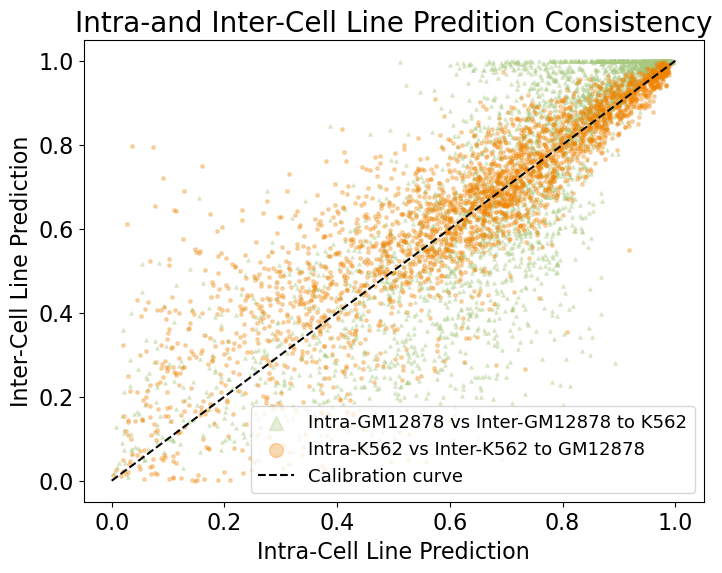

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# 设置图的大小
plt.figure(figsize=(8, 6))

# 画散点图
plt.scatter(pred11, pred12, label='Intra-GM12878 vs Inter-GM12878 to K562', color='#a8c97f', marker='^',s=6, alpha=0.3)
plt.scatter(pred22, pred21, label='Intra-K562 vs Inter-K562 to GM12878', color='#f08300', marker='o',s=6, alpha=0.3)

#'skyblue' 'green'

# 添加对角线
plt.plot([0, 1], [0, 1], '--', color='black', label='Calibration curve')

# 添加标题和标签，使用LaTeX格式使其更专业
plt.title('Intra-and Inter-Cell Line Predition Consistency', fontsize=20)
plt.xlabel(r'Intra-Cell Line Prediction', fontsize=16)
plt.ylabel(r'Inter-Cell Line Prediction', fontsize=16)

# 添加刻度标签的字体大小
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# 添加网格线
#plt.grid(True, linestyle='--', alpha=0.5)

# 添加图例
#plt.legend(fontsize=13)
legend = plt.legend(markerscale=2, scatterpoints=1, fontsize=13)
legend.legendHandles[0]._sizes = [100]
legend.legendHandles[1]._sizes = [100]

# 保存图像为PDF或EPS，以便更好地保留矢量图形
plt.savefig('scatter_plot.png', dpi=300, bbox_inches='tight')

# 显示图
plt.show()


In [54]:
len(pred22)

2979